In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#load the data
df = pd.read_csv('/Users/khush/Documents/GitHub/Sports-analytics-hack/data/statsbomb360_wc22_all_events.csv')
df.head()

/var/folders/56/vf7hl3nd4616f9t3m1rvnx180000gn/T/ipykernel_25711/163424957.py:2: DtypeWarning: Columns (1,4,5,13,18,20,21,31,43,44,46,49,71,76,77,93,94,95,96,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/Users/khush/Documents/GitHub/Sports-analytics-hack/data/statsbomb360_wc22_all_events.csv')


,Unnamed: 0,bad_behaviour_card,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,block_offensive,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,...,half_start_late_video_start,goalkeeper_shot_saved_off_target,shot_saved_off_target,goalkeeper_success_in_play,shot_redirect,goalkeeper_lost_in_play,event_uuid,visible_area,freeze_frame,match_id_y
0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Exploratory Data Analysis

#### Let's understand the data structure and identify possessions that result in shots.

In [3]:
# Check basic info
print("Dataset shape:", df.shape)
print("\nEvent types:")
print(df['type'].value_counts())
print("\nPossessions by team:")
print(df['possession_team'].value_counts())
print("\nTotal unique possessions:", df['possession'].nunique())

Dataset shape: (234652, 119)

Event types:
type
Pass                 68515
Ball Receipt*        63715
Carry                53764
Pressure             16553
Ball Recovery         5821
Duel                  4389
Clearance             2684
Block                 2386
Dribble               1793
Goal Keeper           1790
Foul Committed        1775
Miscontrol            1755
Foul Won              1693
Shot                  1494
Dispossessed          1431
Interception          1371
Dribbled Past         1036
Substitution           587
Injury Stoppage        403
Half Start             286
Half End               286
Tactical Shift         243
50/50                  236
Referee Ball-Drop      162
Starting XI            128
Shield                 104
Player Off              74
Player On               74
Bad Behaviour           44
Error                   28
Offside                 26
Own Goal Against         3
Own Goal For             3
Name: count, dtype: int64

Possessions by team:
possession_te

In [4]:
# Identify possessions that end in shots
# Mark each possession with whether it resulted in a shot

possession_has_shot = df[df['type'] == 'Shot'].groupby('possession')['possession'].first().unique()

df['possession_ends_in_shot'] = df['possession'].isin(possession_has_shot).astype(int)

print("\nPossessions with shots:", df['possession_ends_in_shot'].sum())
print("Possessions without shots:", (1 - df['possession_ends_in_shot']).sum())
print("\nPercentage of possessions ending in shot:", 
      f"{df['possession_ends_in_shot'].mean()*100:.2f}%")


Possessions with shots: 232259
Possessions without shots: 2393

Percentage of possessions ending in shot: 98.98%


In [5]:
# Aggregate to possession level (one row per possession)
possession_data = df.groupby('possession').agg({
    'possession_ends_in_shot': 'first',
    'possession_team': 'first',
    'possession_team_id': 'first',
    'match_id_x': 'first',
    'period': 'first',
    'type': 'count',  # number of events in possession
    'pass_goal_assist': 'sum',  # final pass assists
    'pass_shot_assist': 'sum',  # shot assists
}).reset_index()

possession_data.rename(columns={'type': 'event_count'}, inplace=True)

print("Possession-level data shape:", possession_data.shape)
print("\nPossessions ending in shot by team:")
print(possession_data.groupby('possession_team')['possession_ends_in_shot'].agg(['sum', 'count', 'mean']))
print("\nEvents per possession stats:")
print(possession_data['event_count'].describe())

Possession-level data shape: (274, 9)

Possessions ending in shot by team:
                 sum  count      mean
possession_team                      
Argentina         18     30  0.600000
France             7     11  0.636364
Netherlands       13     19  0.684211
Qatar              5     11  0.454545
Serbia            99    101  0.980198
Switzerland       98    102  0.960784

Events per possession stats:
count     274.000000
mean      856.394161
std       606.657930
min         3.000000
25%       118.000000
50%      1141.500000
75%      1355.500000
max      1966.000000
Name: event_count, dtype: float64


## Understanding Freeze Frame (360 Data)

The freeze_frame column contains coordinates of all visible players during shots. Let's explore this data.

In [6]:
import json
import ast

# Look at freeze frame structure for shots
shots_with_ff = df[df['type'] == 'Shot'].dropna(subset=['shot_freeze_frame'])

print(f"Shots with freeze frame data: {len(shots_with_ff)}")

# Parse a sample freeze frame
if len(shots_with_ff) > 0:
    sample_ff = shots_with_ff.iloc[0]['shot_freeze_frame']
    print("\nSample freeze frame (first shot):")
    print(type(sample_ff))
    
    # Try to parse it
    try:
        ff_data = ast.literal_eval(sample_ff)
        print(f"Number of players in frame: {len(ff_data)}")
        print(f"Sample player data: {ff_data[0] if len(ff_data) > 0 else 'No data'}")
    except:
        print("Could not parse freeze frame")

Shots with freeze frame data: 1436

Sample freeze frame (first shot):
<class 'str'>
Number of players in frame: 12
Sample player data: {'location': [86.2, 51.6], 'player': {'id': 3831, 'name': 'Dušan Tadić'}, 'position': {'id': 19, 'name': 'Center Attacking Midfield'}, 'teammate': False}


In [7]:
# Check other key columns for understanding possessions
print("Possession types by event:")
possession_events = df.groupby(['possession', 'type']).size().reset_index(name='count')
print(possession_events.head(20))

print("\n\nMost common event types in possessions:")
event_types = df[df['type'] != 'Shot'].groupby('type').size().sort_values(ascending=False).head(10)
print(event_types)

# Check pass outcomes
print("\n\nPass outcomes:")
print(df[df['type'] == 'Pass']['pass_outcome'].value_counts())

Possession types by event:
    possession             type  count
0            1       Half Start    128
1            1      Starting XI    128
2            2            50/50      2
3            2    Ball Receipt*    435
4            2    Ball Recovery     20
5            2            Block     10
6            2            Carry    361
7            2        Clearance     20
8            2     Dispossessed      9
9            2          Dribble      6
10           2    Dribbled Past      5
11           2             Duel     31
12           2   Foul Committed      8
13           2         Foul Won      8
14           2      Goal Keeper      6
15           2  Injury Stoppage      3
16           2     Interception      3
17           2       Miscontrol     11
18           2             Pass    465
19           2         Pressure     83


Most common event types in possessions:
type
Pass             68515
Ball Receipt*    63715
Carry            53764
Pressure         16553
Ball Recovery  

## Possession Definition & Metrics

Let's compute key possession metrics that could predict shot outcomes.

In [8]:
# For each possession, compute useful metrics
possession_stats = []

for poss_id in df['possession'].unique():
    poss_events = df[df['possession'] == poss_id].sort_values('index')
    
    if len(poss_events) == 0:
        continue
    
    # Basic info
    team = poss_events.iloc[0]['possession_team']
    team_id = poss_events.iloc[0]['possession_team_id']
    match = poss_events.iloc[0]['match_id_x']
    
    # Check if ends in shot
    ends_in_shot = (poss_events['type'] == 'Shot').any()
    
    # Count events
    num_events = len(poss_events)
    num_passes = (poss_events['type'] == 'Pass').sum()
    num_failed_passes = (poss_events['pass_outcome'] == 'Incomplete').sum()
    num_dribbles = (poss_events['type'] == 'Dribble').sum()
    
    # Progression metrics
    passes = poss_events[poss_events['type'] == 'Pass']
    total_pass_length = passes['pass_length'].sum() if 'pass_length' in passes.columns else 0
    avg_pass_length = passes['pass_length'].mean() if 'pass_length' in passes.columns else 0
    
    # Location progression
    locs = poss_events[poss_events['location'].notna()]['location'].tolist()
    if len(locs) > 0:
        try:
            first_loc = ast.literal_eval(locs[0]) if isinstance(locs[0], str) else locs[0]
            last_loc = ast.literal_eval(locs[-1]) if isinstance(locs[-1], str) else locs[-1]
            progression = ((last_loc[0] - first_loc[0])**2 + (last_loc[1] - first_loc[1])**2)**0.5
        except:
            progression = 0
    else:
        progression = 0
    
    # Under pressure
    under_pressure = (poss_events['under_pressure'] == True).sum()
    
    possession_stats.append({
        'possession_id': poss_id,
        'team': team,
        'team_id': team_id,
        'match_id': match,
        'ends_in_shot': int(ends_in_shot),
        'num_events': num_events,
        'num_passes': num_passes,
        'num_failed_passes': num_failed_passes,
        'pass_accuracy': num_passes / (num_passes + num_failed_passes) if (num_passes + num_failed_passes) > 0 else 0,
        'num_dribbles': num_dribbles,
        'total_pass_length': total_pass_length,
        'avg_pass_length': avg_pass_length,
        'progression_distance': progression,
        'times_under_pressure': under_pressure,
    })

poss_features_df = pd.DataFrame(possession_stats)
print("Possession features shape:", poss_features_df.shape)
print("\nBasic stats - Possessions WITH shots:")
print(poss_features_df[poss_features_df['ends_in_shot'] == 1][['num_events', 'num_passes', 'pass_accuracy', 'avg_pass_length']].describe())

print("\nBasic stats - Possessions WITHOUT shots:")
print(poss_features_df[poss_features_df['ends_in_shot'] == 0][['num_events', 'num_passes', 'pass_accuracy', 'avg_pass_length']].describe())

Possession features shape: (274, 14)

Basic stats - Possessions WITH shots:
        num_events  num_passes  pass_accuracy  avg_pass_length
count   240.000000  240.000000     240.000000       240.000000
mean    967.745833  282.900000       0.867225        21.342493
std     565.226246  167.675863       0.058976         3.151884
min       5.000000    1.000000       0.500000        11.718455
25%     461.750000  128.000000       0.849690        20.220938
50%    1195.500000  347.000000       0.870188        21.085479
75%    1383.500000  410.250000       0.883954        22.073778
max    1966.000000  571.000000       1.000000        43.288128

Basic stats - Possessions WITHOUT shots:
       num_events  num_passes  pass_accuracy  avg_pass_length
count   34.000000   34.000000      34.000000        33.000000
mean    70.382353   18.205882       0.835789        24.472262
std     64.160790   17.440426       0.183903         6.839050
min      3.000000    0.000000       0.000000        15.813555
25%  

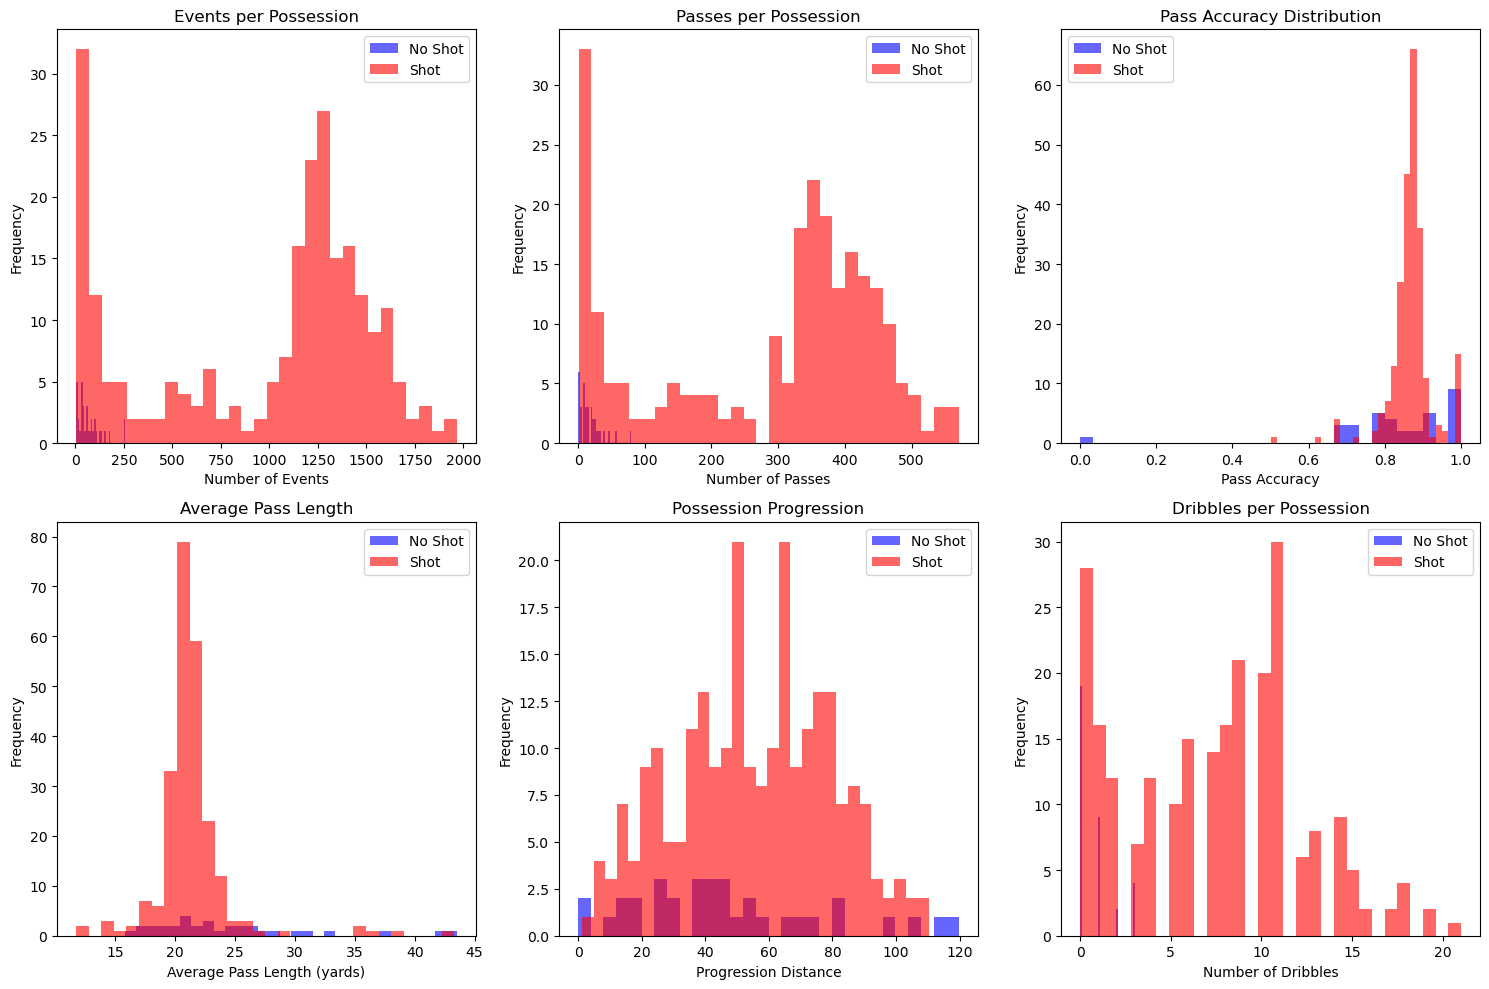

In [9]:
# Visualizations
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Event count distribution
axes[0, 0].hist(poss_features_df[poss_features_df['ends_in_shot'] == 0]['num_events'], 
                 bins=30, alpha=0.6, label='No Shot', color='blue')
axes[0, 0].hist(poss_features_df[poss_features_df['ends_in_shot'] == 1]['num_events'], 
                 bins=30, alpha=0.6, label='Shot', color='red')
axes[0, 0].set_xlabel('Number of Events')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Events per Possession')
axes[0, 0].legend()

# 2. Number of passes
axes[0, 1].hist(poss_features_df[poss_features_df['ends_in_shot'] == 0]['num_passes'], 
                 bins=30, alpha=0.6, label='No Shot', color='blue')
axes[0, 1].hist(poss_features_df[poss_features_df['ends_in_shot'] == 1]['num_passes'], 
                 bins=30, alpha=0.6, label='Shot', color='red')
axes[0, 1].set_xlabel('Number of Passes')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Passes per Possession')
axes[0, 1].legend()

# 3. Pass accuracy
axes[0, 2].hist(poss_features_df[poss_features_df['ends_in_shot'] == 0]['pass_accuracy'], 
                 bins=30, alpha=0.6, label='No Shot', color='blue')
axes[0, 2].hist(poss_features_df[poss_features_df['ends_in_shot'] == 1]['pass_accuracy'], 
                 bins=30, alpha=0.6, label='Shot', color='red')
axes[0, 2].set_xlabel('Pass Accuracy')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].set_title('Pass Accuracy Distribution')
axes[0, 2].legend()

# 4. Average pass length
axes[1, 0].hist(poss_features_df[poss_features_df['ends_in_shot'] == 0]['avg_pass_length'].dropna(), 
                 bins=30, alpha=0.6, label='No Shot', color='blue')
axes[1, 0].hist(poss_features_df[poss_features_df['ends_in_shot'] == 1]['avg_pass_length'].dropna(), 
                 bins=30, alpha=0.6, label='Shot', color='red')
axes[1, 0].set_xlabel('Average Pass Length (yards)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Average Pass Length')
axes[1, 0].legend()

# 5. Progression distance
axes[1, 1].hist(poss_features_df[poss_features_df['ends_in_shot'] == 0]['progression_distance'], 
                 bins=30, alpha=0.6, label='No Shot', color='blue')
axes[1, 1].hist(poss_features_df[poss_features_df['ends_in_shot'] == 1]['progression_distance'], 
                 bins=30, alpha=0.6, label='Shot', color='red')
axes[1, 1].set_xlabel('Progression Distance')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Possession Progression')
axes[1, 1].legend()

# 6. Number of dribbles
axes[1, 2].hist(poss_features_df[poss_features_df['ends_in_shot'] == 0]['num_dribbles'], 
                 bins=30, alpha=0.6, label='No Shot', color='blue')
axes[1, 2].hist(poss_features_df[poss_features_df['ends_in_shot'] == 1]['num_dribbles'], 
                 bins=30, alpha=0.6, label='Shot', color='red')
axes[1, 2].set_xlabel('Number of Dribbles')
axes[1, 2].set_ylabel('Frequency')
axes[1, 2].set_title('Dribbles per Possession')
axes[1, 2].legend()

plt.tight_layout()
plt.show()

In [10]:
# Correlation with shot outcome
correlations = poss_features_df[['ends_in_shot', 'num_events', 'num_passes', 'pass_accuracy', 
                                   'avg_pass_length', 'progression_distance', 'num_dribbles', 
                                   'times_under_pressure']].corr()['ends_in_shot'].sort_values(ascending=False)

print("Feature correlations with shot outcome:")
print(correlations)

Feature correlations with shot outcome:
ends_in_shot            1.000000
times_under_pressure    0.496088
num_events              0.488554
num_passes              0.486492
num_dribbles            0.428758
pass_accuracy           0.122016
progression_distance    0.103264
avg_pass_length        -0.261515
Name: ends_in_shot, dtype: float64


## Missing Values Analysis

Check for NaN values across the dataset to understand data completeness.

In [11]:
# Check NaN values across entire dataset
print("="*70)
print("MISSING VALUES IN MAIN DATASET (df)")
print("="*70)

nan_counts = df.isnull().sum()
nan_percent = (df.isnull().sum() / len(df)) * 100

# Sort by percentage missing
nan_summary = pd.DataFrame({
    'Column': nan_counts.index,
    'NaN_Count': nan_counts.values,
    'Percent_Missing': nan_percent.values
}).sort_values('Percent_Missing', ascending=False)

# Show columns with any missing values
nan_columns = nan_summary[nan_summary['NaN_Count'] > 0]
print(f"\nColumns with missing values: {len(nan_columns)} out of {len(df.columns)}")
print("\nTop 20 columns with most missing values:")
print(nan_columns.head(20).to_string(index=False))

print("\n" + "="*70)
print("KEY COLUMNS STATUS")
print("="*70)

key_cols = ['location', 'pass_end_location', 'pass_length', 'under_pressure', 
            'shot_freeze_frame', 'freeze_frame', 'shot_outcome', 'pass_outcome']

for col in key_cols:
    if col in df.columns:
        missing = df[col].isnull().sum()
        pct = (missing / len(df)) * 100
        print(f"{col:30s}: {missing:7d} ({pct:5.1f}%)")
    else:
        print(f"{col:30s}: COLUMN NOT FOUND")

MISSING VALUES IN MAIN DATASET (df)

Columns with missing values: 104 out of 120

Top 20 columns with most missing values:
                          Column  NaN_Count  Percent_Missing
         goalkeeper_lost_in_play     234651        99.999574
      goalkeeper_success_in_play     234651        99.999574
     half_start_late_video_start     234650        99.999148
                   shot_redirect     234650        99.999148
goalkeeper_shot_saved_off_target     234650        99.999148
           shot_saved_off_target     234650        99.999148
            shot_follows_dribble     234649        99.998722
   goalkeeper_shot_saved_to_post     234649        99.998722
              shot_saved_to_post     234649        99.998722
                block_save_block     234643        99.996165
          goalkeeper_punched_out     234640        99.994886
                dribble_no_touch     234640        99.994886
                  shot_open_goal     234639        99.994460
                foul_wo

In [12]:
# Check NaN values in our engineered possession features
print("\n" + "="*70)
print("MISSING VALUES IN POSSESSION FEATURES (poss_features_df)")
print("="*70)

poss_nan = poss_features_df.isnull().sum()
poss_nan_pct = (poss_features_df.isnull().sum() / len(poss_features_df)) * 100

poss_summary = pd.DataFrame({
    'Column': poss_nan.index,
    'NaN_Count': poss_nan.values,
    'Percent_Missing': poss_nan_pct.values
}).sort_values('Percent_Missing', ascending=False)

print("\nMissing values by feature:")
print(poss_summary.to_string(index=False))

# Check specific critical features
print("\n" + "="*70)
print("CRITICAL FEATURES FOR MODELING")
print("="*70)
print(f"Pass accuracy complete: {(poss_features_df['pass_accuracy'].notna()).sum()} / {len(poss_features_df)}")
print(f"Avg pass length complete: {(poss_features_df['avg_pass_length'].notna()).sum()} / {len(poss_features_df)}")
print(f"Progression distance complete: {(poss_features_df['progression_distance'].notna()).sum()} / {len(poss_features_df)}")


MISSING VALUES IN POSSESSION FEATURES (poss_features_df)

Missing values by feature:
              Column  NaN_Count  Percent_Missing
     avg_pass_length          1         0.364964
       possession_id          0         0.000000
                team          0         0.000000
             team_id          0         0.000000
            match_id          0         0.000000
        ends_in_shot          0         0.000000
          num_events          0         0.000000
          num_passes          0         0.000000
   num_failed_passes          0         0.000000
       pass_accuracy          0         0.000000
        num_dribbles          0         0.000000
   total_pass_length          0         0.000000
progression_distance          0         0.000000
times_under_pressure          0         0.000000

CRITICAL FEATURES FOR MODELING
Pass accuracy complete: 274 / 274
Avg pass length complete: 273 / 274
Progression distance complete: 274 / 274


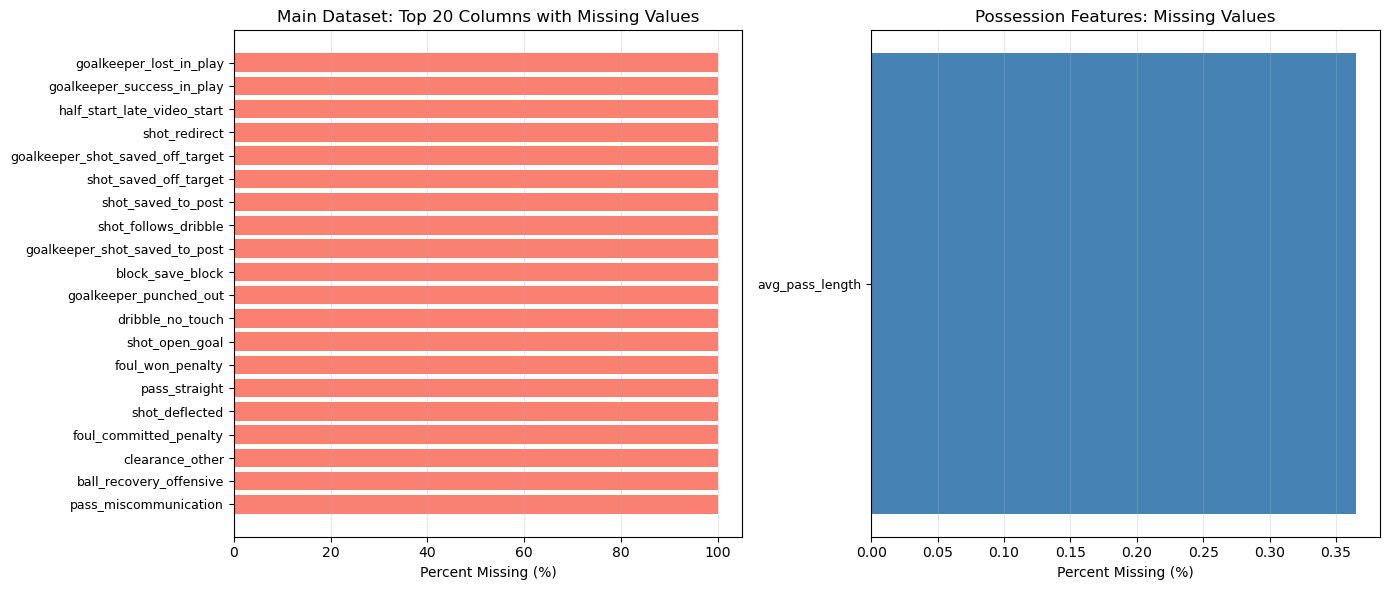

In [13]:
# Visualize NaN distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Main dataset NaN percentages (top 20)
top_nan = nan_summary.head(20).sort_values('Percent_Missing')
axes[0].barh(range(len(top_nan)), top_nan['Percent_Missing'].values, color='salmon')
axes[0].set_yticks(range(len(top_nan)))
axes[0].set_yticklabels(top_nan['Column'].values, fontsize=9)
axes[0].set_xlabel('Percent Missing (%)')
axes[0].set_title('Main Dataset: Top 20 Columns with Missing Values')
axes[0].grid(axis='x', alpha=0.3)

# Plot 2: Possession features NaN
poss_with_nan = poss_summary[poss_summary['NaN_Count'] > 0].sort_values('Percent_Missing')
if len(poss_with_nan) > 0:
    axes[1].barh(range(len(poss_with_nan)), poss_with_nan['Percent_Missing'].values, color='steelblue')
    axes[1].set_yticks(range(len(poss_with_nan)))
    axes[1].set_yticklabels(poss_with_nan['Column'].values, fontsize=9)
    axes[1].set_xlabel('Percent Missing (%)')
    axes[1].set_title('Possession Features: Missing Values')
    axes[1].grid(axis='x', alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'No missing values in possession features!', 
                 ha='center', va='center', transform=axes[1].transAxes, fontsize=12)
    axes[1].set_title('Possession Features: Missing Values')

plt.tight_layout()
plt.show()